In [1]:
pip install colorednoise #instala biblioteca para ruído rosa

Iniciando a Simulação de Monte Carlo... Isso pode levar alguns segundos.
Processando nível de ruído: 0.1
Processando nível de ruído: 0.3
Processando nível de ruído: 0.5
Processando nível de ruído: 0.7
Processando nível de ruído: 0.9


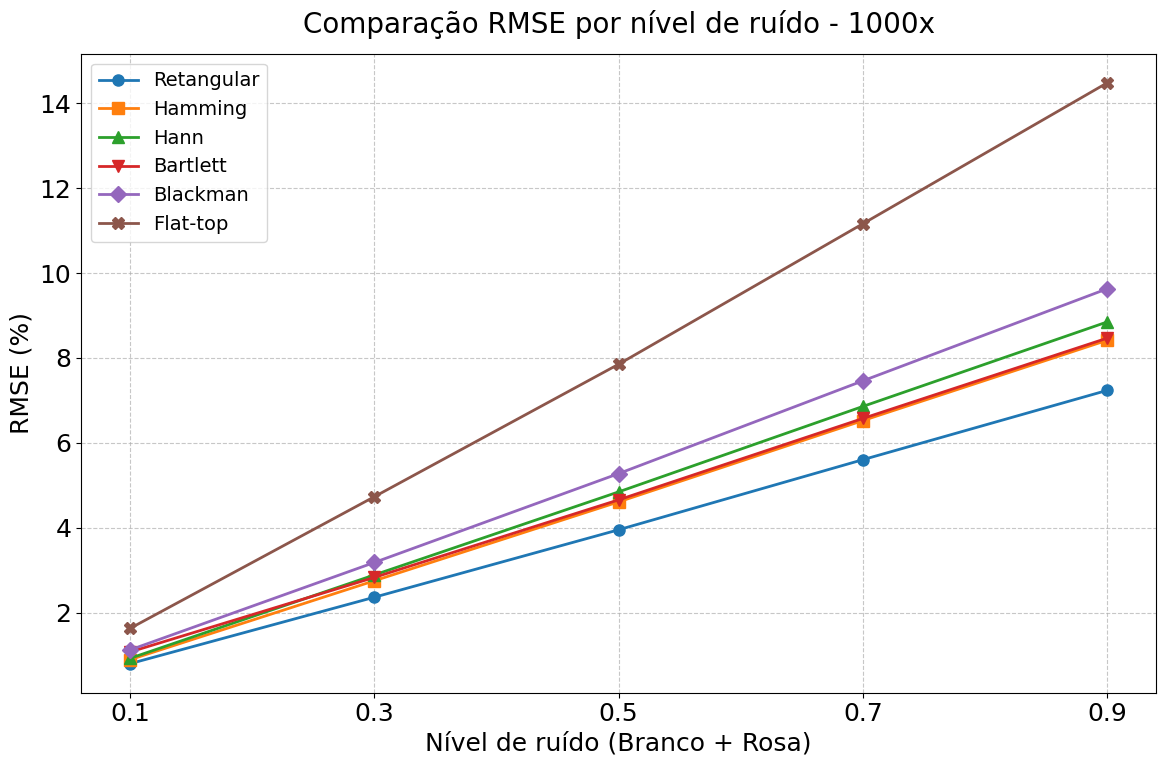

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq
from scipy.signal import get_window
import colorednoise as cn

# Configuração de semente para reprodutibilidade
np.random.seed(100)

def generate_signal(LEAK, N, fs, noise_level):
    T = 1.0 / fs
    df = 1 / (N * T)
    chopper = 20.0
    rede = 60.0

    FN1 = np.round(chopper * N * T)
    FN2 = np.round(rede * N * T)
    if LEAK:
        FN1 += 0.5
        FN2 += 0.5

    chopper = FN1 * df
    centro_gaussiana = (N*T) / 2
    desvio_padrao = (N*T) / 10
    amplitude_gaussiana = 2.0

    x = np.linspace(0.0, N * T, N, endpoint=False)
    y0_ = np.sin(chopper * 2.0 * np.pi * x)
    gaussiana = amplitude_gaussiana * np.exp(-(x - centro_gaussiana)**2 / (2 * desvio_padrao**2))
    y0 = y0_ * gaussiana

    phase = np.random.rand(1)
    y1 = 0.2 * np.sin(rede * 2.0 * np.pi * x - phase)

    # Gerando ruídos com base no nível estipulado
    noise = np.random.normal(0.0, 1.0, N)
    pink_noise = cn.powerlaw_psd_gaussian(1, N)
    lowfreq = 2.0
    delta_ampl = np.cos(lowfreq * 2.0 * np.pi * x)

    # Aplicação do multiplicador de ruído solicitado
    y = (y0 + y1 + noise * noise_level + pink_noise * noise_level) + delta_ampl * 0.5

    return x, y, gaussiana

# Parâmetros de simulação
N = 30000
fs = 1000
T = 1.0 / fs
segment_length = int(fs)
num_segments = int(N / segment_length)
num_simulations = 1000  # Quantidade de execuções por nível de ruído

# Níveis de ruído solicitados (0.1 até 0.9)
noise_levels = np.arange(0.1, 1.0, 0.2)

windows = ['boxcar', 'hamming', 'hann', 'bartlett', 'blackman', 'flattop']
window_names = ['Retangular', 'Hamming', 'Hann', 'Bartlett', 'Blackman', 'Flat-top']
correction_calc = [1.0, 1.85, 2.0, 2.02, 2.40, 4.68]

# Frequências e índice do pico de interest (20 Hz)
xf = fftfreq(segment_length, T)[:segment_length//2]
idx_20hz = np.argmin(np.abs(xf - 20))
segment_centers = np.linspace(0, N*T, num_segments, endpoint=False) + 0.5

# Referência ideal da amplitude gaussiana no centro de cada segmento
centro_gaussiana = (N*T) / 2
desvio_padrao = (N*T) / 10
amplitude_gaussiana = 2.0
gaussiana_ideal = amplitude_gaussiana * np.exp(-(segment_centers - centro_gaussiana)**2 / (2 * desvio_padrao**2))

# Dicionário para armazenar o erro médio por janela e por nível de ruído
# Avaliaremos o cenário COM LEAKAGE usando o Fator Corrigido
results = {win: [] for win in windows}

print("Iniciando a Simulação de Monte Carlo... Isso pode levar alguns segundos.")

for noise in noise_levels:
    print(f"Processando nível de ruído: {noise:.1f}")

    # Inicializa acumuladores de erro para esta rodada de ruído
    error_accumulator = {win: 0.0 for win in windows}

    for sim in range(num_simulations):
        # Gerar sinal com Leakage para o teste de estresse
        _, y_leak, _ = generate_signal(True, N, fs, noise)

        for win, cf_c in zip(windows, correction_calc):
            w = get_window(win, segment_length)
            sim_errors = []

            for seg in range(num_segments):
                start = seg * segment_length
                end = start + segment_length
                y_segment = y_leak[start:end] * w

                # Transformada Rápida de Fourier
                yf = fft(y_segment)
                yf_plot = 2.0 / segment_length * np.abs(yf[:segment_length//2]) * cf_c

                # Amplitude calculada no pico de 20 Hz
                amplitude_detectada = yf_plot[idx_20hz]
                amplitude_real = gaussiana_ideal[seg]

                # Erro absoluto nesta janela/segmento
                sim_errors.append(np.abs(amplitude_detectada - amplitude_real))

            # Acumula o erro médio dos segmentos desta simulação
            error_accumulator[win] += np.mean(sim_errors)

    # Calcula o erro médio final das 1000 simulações para cada janela
    for win in windows:
        results[win].append(error_accumulator[win] / num_simulations*100)


## Plotagem dos Resultados Estatísticos

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 18})

markers = ['o', 's', '^', 'v', 'D', 'X']
for win, name, marker in zip(windows, window_names, markers):
    plt.plot(noise_levels, results[win], marker=marker, label=f'{name}', lw=2, ms=8)

plt.title(f"Comparação RMSE por nível de ruído - {num_simulations}x", fontsize=20, pad=15)
#plt.title(f"RMSE comparison by Window type and noise level - simulated gaussian signal - {num_simulations}x", fontsize=16, pad=15)
plt.xlabel('Nível de ruído (Branco + Rosa)', fontsize=18)
#plt.xlabel('Noise level (white and pink)', fontsize=18)
plt.ylabel('RMSE (%)', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(noise_levels)
plt.legend(fontsize=14, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq
from scipy.signal import get_window
import colorednoise as cn

# Configuração de semente para reprodutibilidade
np.random.seed(100)

def generate_signal(LEAK, N, fs, noise_level):
    T = 1.0 / fs
    df = 1 / (N * T)
    chopper = 20.0
    rede = 60.0

    FN1 = np.round(chopper * N * T)
    FN2 = np.round(rede * N * T)
    if LEAK:
        FN1 += 0.5
        FN2 += 0.5

    chopper = FN1 * df
    centro_gaussiana = (N*T) / 2
    desvio_padrao = (N*T) / 10
    amplitude_gaussiana = 2.0

    x = np.linspace(0.0, N * T, N, endpoint=False)
    y0_ = np.sin(chopper * 2.0 * np.pi * x)
    gaussiana = amplitude_gaussiana * np.exp(-(x - centro_gaussiana)**2 / (2 * desvio_padrao**2))
    y0 = y0_ * gaussiana

    phase = np.random.rand(1)
    y1 = 0.2 * np.sin(rede * 2.0 * np.pi * x - phase)

    # Gerando ruídos com base no nível estipulado
    noise = np.random.normal(0.0, 1.0, N)
    pink_noise = cn.powerlaw_psd_gaussian(1, N)
    lowfreq = 2.0
    delta_ampl = np.cos(lowfreq * 2.0 * np.pi * x)

    # Aplicação do multiplicador de ruído solicitado
    y = (y0 + y1 + noise * noise_level + pink_noise * noise_level) + delta_ampl * 0.5

    return x, y, gaussiana

# Parâmetros de simulação
N = 30000
fs = 1000
T = 1.0 / fs
segment_length = int(fs)
num_segments = int(N / segment_length)
num_simulations = 1000  # Quantidade de execuções por nível de ruído

# Níveis de ruído solicitados (0.1 até 0.9)
noise_levels = np.arange(0.1, 1.0, 0.2)

windows = ['boxcar', 'hamming', 'hann', 'bartlett', 'blackman', 'flattop']
window_names = ['Retangular', 'Hamming', 'Hann', 'Bartlett', 'Blackman', 'Flat-top']
correction_calc = [1.0, 1.85, 2.0, 2.02, 2.40, 4.68]

# Frequências e índice do pico de interesse (20 Hz)
xf = fftfreq(segment_length, T)[:segment_length//2]
idx_20hz = np.argmin(np.abs(xf - 20))
segment_centers = np.linspace(0, N*T, num_segments, endpoint=False) + 0.5

# Referência ideal da amplitude gaussiana no centro de cada segmento
centro_gaussiana = (N*T) / 2
desvio_padrao = (N*T) / 10
amplitude_gaussiana = 2.0
gaussiana_ideal = amplitude_gaussiana * np.exp(-(segment_centers - centro_gaussiana)**2 / (2 * desvio_padrao**2))

# Estruturas para armazenar as médias e desvios padrões para os plots
rmse_means = {win: [] for win in windows}
rmse_stds = {win: [] for win in windows}

print("Iniciando a Simulação de Monte Carlo... Isso pode levar alguns segundos.")

for noise in noise_levels:
    print(f"Processando nível de ruído: {noise:.1f}")

    # Listas temporárias para guardar o histórico de RMSE de cada uma das 1000 rodadas
    sim_results_history = {win: [] for win in windows}

    for sim in range(num_simulations):
        # Gerar sinal com Leakage para o teste de estresse
        _, y_leak, _ = generate_signal(True, N, fs, noise)

        for win, cf_c in zip(windows, correction_calc):
            w = get_window(win, segment_length)
            segment_squared_errors = []

            for seg in range(num_segments):
                start = seg * segment_length
                end = start + segment_length
                y_segment = y_leak[start:end] * w

                # Transformada Rápida de Fourier
                yf = fft(y_segment)
                yf_plot = 2.0 / segment_length * np.abs(yf[:segment_length//2]) * cf_c

                # Amplitude calculada no pico de 20 Hz
                amplitude_detectada = yf_plot[idx_20hz]
                amplitude_real = gaussiana_ideal[seg]

                # Erro quadrático para o cômputo do RMSE verdadeiro
                squared_error = (amplitude_detectada - amplitude_real) ** 2
                segment_squared_errors.append(squared_error)

            # Calcula o RMSE desta simulação específica (%)
            rmse_single_sim = np.sqrt(np.mean(segment_squared_errors)) * 100
            sim_results_history[win].append(rmse_single_sim)

    # Computa as métricas estatísticas agregadas do Monte Carlo para o nível de ruído atual
    for win in windows:
        rmse_means[win].append(np.mean(sim_results_history[win]))
        rmse_stds[win].append(np.std(sim_results_history[win]))


## Plotagem dos Resultados Estatísticos com Barras de Erro

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 18})

markers = ['o', 'o', 'o', 'o', 'o', 'o']

for win, name, marker in zip(windows, window_names, markers):
    # Substituído plt.plot por plt.errorbar para inclusão dos desvios padrões
    plt.errorbar(noise_levels, rmse_means[win], yerr=rmse_stds[win],
                 marker=marker, label=f'{name}', lw=2, ms=8, capsize=5, elinewidth=1.5)

#plt.title(f"RMSE comparison by Window type and noise level - simulated gaussian signal - {num_simulations}x", fontsize=20, pad=15)
plt.title(f"Comparação RMSE por nível de ruído - sinal gaussiano - {num_simulations}x", fontsize=20, pad=15)
#plt.xlabel('Noise level (white and pink)', fontsize=16)
plt.xlabel('Nível de ruído (branco + rosa)', fontsize=18)
plt.ylabel('RMSE (%)', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(noise_levels)
plt.legend(fontsize=16, loc='upper left')
plt.tight_layout()
plt.show()

Iniciando a Simulação de Monte Carlo... Isso pode levar alguns segundos.
Processando nível de ruído: 0.1
Processando nível de ruído: 0.3
Processando nível de ruído: 0.5


In [ ]:
import numpy as np
from scipy.fftpack import fft
from scipy.signal import get_window

# Certificando que a lista unitária existe no ambiente
correction_unit = [1.0] * 6

def calcular_rmse(win, cf, noise_level, leakage, num_simulations=1000):
    """
    Calcula o RMSE médio ao longo de 1000 simulações de Monte Carlo
    para uma janela, fator de correção e nível de ruído específicos.
    """
    w = get_window(win, segment_length)
    squared_errors_sum = 0.0
    total_segments_processed = num_simulations * num_segments

    # Fixamos a semente no início do cálculo para que o 'Unitário' e o 'Corrigido'
    # sejam avaliados exatamente sob as mesmas 1000 realizações de ruído.
    np.random.seed(42)

    for sim in range(num_simulations):
        # Gera o sinal correspondente (com ou sem leakage)
        _, y_signal, _ = generate_signal(leakage, N, fs, noise_level)

        for seg in range(num_segments):
            start = seg * segment_length
            end = start + segment_length
            y_segment = y_signal[start:end] * w

            # FFT e aplicação do fator de correção
            yf = fft(y_segment)
            yf_plot = 2.0 / segment_length * np.abs(yf[:segment_length//2]) * cf

            # Cálculo do erro do pico de 20 Hz em relação ao valor ideal
            erro = yf_plot[idx_20hz] - gaussiana_ideal[seg]
            squared_errors_sum += erro ** 2

    # Retorna a raiz do erro quadrático médio (RMSE)
    return np.sqrt(squared_errors_sum / total_segments_processed)

print("Calculando o RMSE para as 1000 simulações (isso pode levar cerca de 1 a 2 minutos)...")

# Cabeçalho da tabela LaTeX (seu modelo original)
latex = r"""\begin{longtable}{cccccc}
\caption{RMSE por janela, ruído, leakage e fator de correção} \\
\label{tab:rmse_completo}\\
\toprule
\multirow{2}{*}{Janela} & \multirow{2}{*}{Ruído} & \multicolumn{4}{c}{RMSE} \\
\cmidrule(lr){3-6}
& & Unitário s/Leakage & Unitário c/Leakage & Corrigido s/Leakage & Corrigido c/Leakage \\
\midrule
\endfirsthead

\caption[]{RMSE por janela, ruído, leakage e fator de correção (continuação)} \\
\toprule
\multirow{2}{*}{Janela} & \multirow{2}{*}{Ruído} & \multicolumn{4}{c}{RMSE} \\
\cmidrule(lr){3-6}
& & Unitário s/Leakage & Unitário c/Leakage & Corrigido s/Leakage & Corrigido c/Leakage \\
\midrule
\endhead

\bottomrule
\endfoot
"""

# Geração das linhas da tabela utilizando a função otimizada
for win, name, cf_u, cf_c in zip(windows, window_names, correction_unit, correction_calc):
    latex += f"% Janela {name}\n"
    latex += f"\\multirow{{5}}{{*}}{{{name}}}"
    for i, noise_amp in enumerate(noise_levels):
        rmse_u_nl = calcular_rmse(win, cf_u, noise_amp, leakage=False)
        rmse_u_lk = calcular_rmse(win, cf_u, noise_amp, leakage=True)
        rmse_c_nl = calcular_rmse(win, cf_c, noise_amp, leakage=False)
        rmse_c_lk = calcular_rmse(win, cf_c, noise_amp, leakage=True)

        # Se não for a primeira linha da janela, não repete o nome da janela (multi-row do LaTeX)
        if i == 0:
            line = f" & {noise_amp:.1f} & {rmse_u_nl:.5f} & {rmse_u_lk:.5f} & {rmse_c_nl:.5f} & {rmse_c_lk:.5f} \\\\\n"
        else:
            line = f" & {noise_amp:.1f} & {rmse_u_nl:.5f} & {rmse_u_lk:.5f} & {rmse_c_nl:.5f} & {rmse_c_lk:.5f} \\\\\n"

        latex += line
    latex += "\\midrule\n"

latex += "\\end{longtable}"

print("\n--- CÓDIGO LATEX GERADO --- \n")
print(latex)